In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
# Set style for professional-looking charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('../data/Superstore.csv', encoding='latin-1')
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=False)

In [3]:
# Create discount bins
df['discount_bin'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 1.0],
    labels=['0%', '1-5%', '6-10%', '11-15%', '16-20%', '21-25%', '26-30%', '31-40%', '41-50%', '50%+']
)

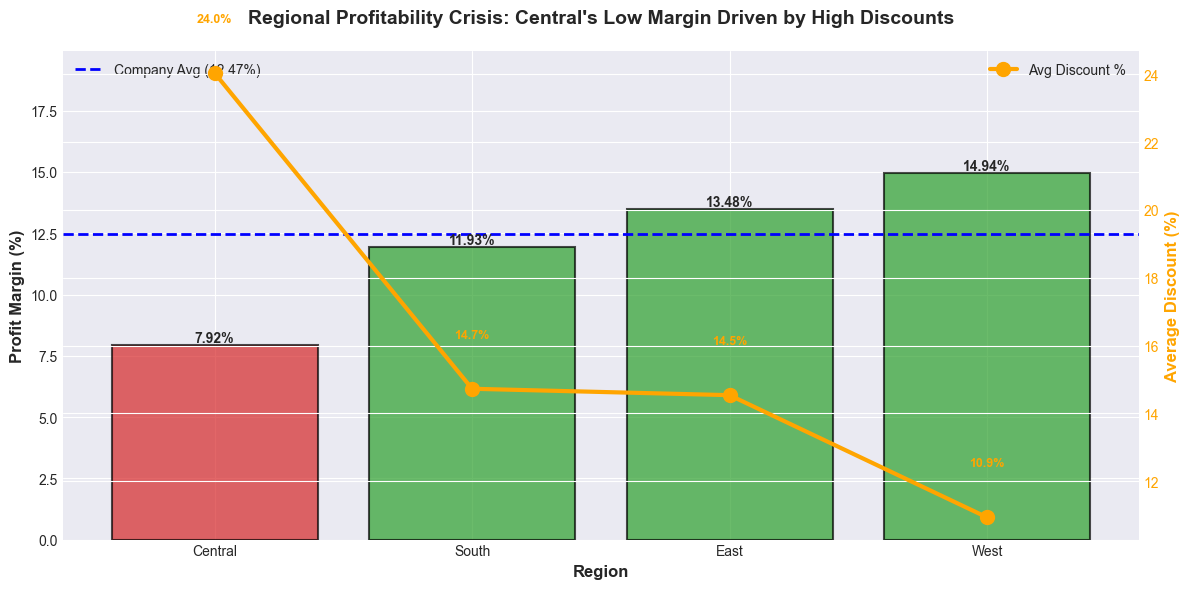

In [4]:
# ============================================================================
# VISUALIZATION 1: Regional Performance Comparison
# ============================================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

region_metrics = df.groupby('region').agg({
    'sales': 'sum',
    'profit': 'sum',
    'discount': 'mean'
}).reset_index()
region_metrics['profit_margin_%'] = (region_metrics['profit'] / region_metrics['sales'] * 100)
region_metrics['avg_discount_%'] = region_metrics['discount'] * 100
region_metrics = region_metrics.sort_values('profit_margin_%')

# Bar chart for profit margin
colors = ['#d62728' if x < 10 else '#2ca02c' for x in region_metrics['profit_margin_%']]
bars = ax1.bar(region_metrics['region'], region_metrics['profit_margin_%'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Profit Margin (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Region', fontsize=12, fontweight='bold')
ax1.axhline(y=12.47, color='blue', linestyle='--', linewidth=2, label='Company Avg (12.47%)')
ax1.set_ylim(0, max(region_metrics['profit_margin_%']) + 5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Line chart for discount rate (secondary axis)
ax2 = ax1.twinx()
line = ax2.plot(region_metrics['region'], region_metrics['avg_discount_%'],
                color='orange', marker='o', linewidth=3, markersize=10, label='Avg Discount %')
ax2.set_ylabel('Average Discount (%)', fontsize=12, fontweight='bold', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Add value labels on line
for i, (x, y) in enumerate(zip(region_metrics['region'], region_metrics['avg_discount_%'])):
    ax2.text(i, y + 1.5, f'{y:.1f}%', ha='center', fontweight='bold', fontsize=9, color='orange')

plt.title('Regional Profitability Crisis: Central\'s Low Margin Driven by High Discounts',
          fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('viz1_regional_performance.png', dpi=300, bbox_inches='tight')
plt.show()

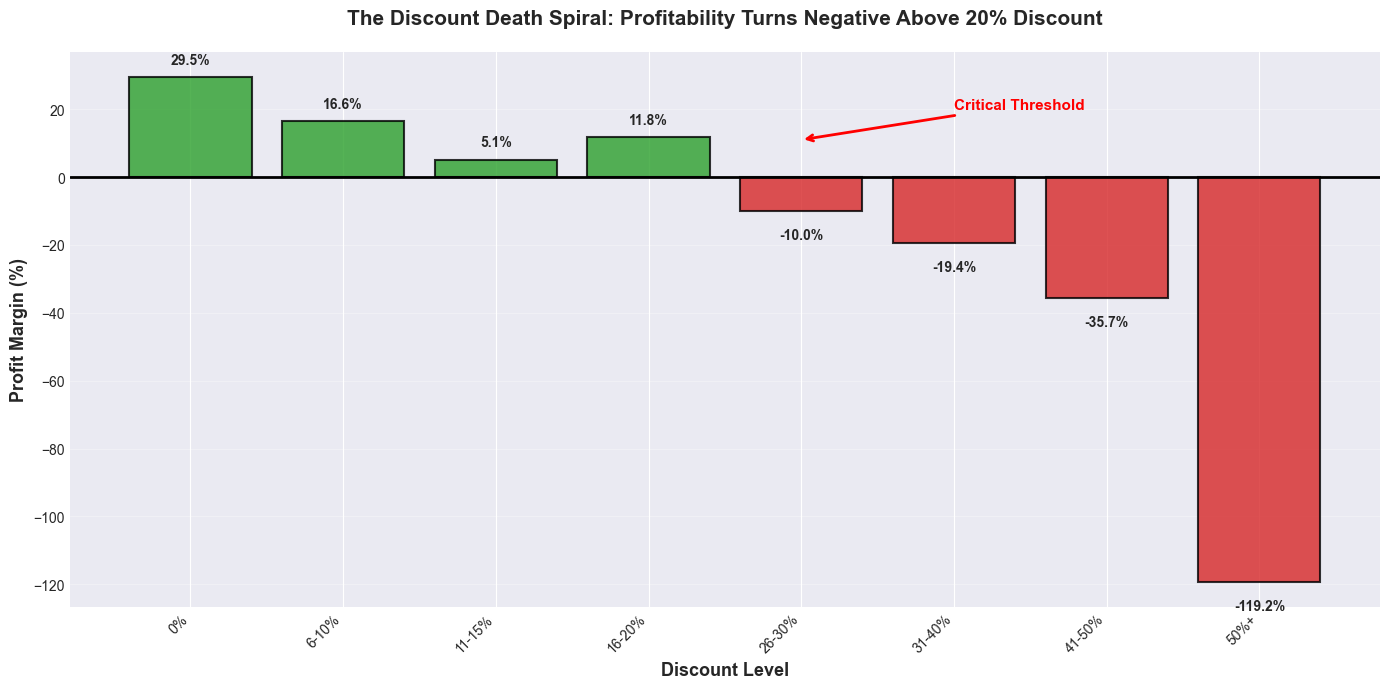

In [5]:
# ============================================================================
# VISUALIZATION 2: Discount Impact on Profitability
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 7))

discount_impact = df.groupby('discount_bin', observed=True).agg({
    'profit': 'sum',
    'sales': 'sum',
    'order_id': 'count'
}).reset_index()
discount_impact['profit_margin_%'] = (discount_impact['profit'] / discount_impact['sales'] * 100)

# Create color map: green for positive, red for negative
colors = ['#2ca02c' if x > 0 else '#d62728' for x in discount_impact['profit_margin_%']]

bars = ax.bar(discount_impact['discount_bin'], discount_impact['profit_margin_%'],
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add horizontal line at zero
ax.axhline(y=0, color='black', linestyle='-', linewidth=2)

# Add value labels
for bar in bars:
    height = bar.get_height()
    label_y = height + 3 if height > 0 else height - 5
    ax.text(bar.get_x() + bar.get_width()/2., label_y,
            f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top',
            fontweight='bold', fontsize=10)

ax.set_xlabel('Discount Level', fontsize=13, fontweight='bold')
ax.set_ylabel('Profit Margin (%)', fontsize=13, fontweight='bold')
ax.set_title('The Discount Death Spiral: Profitability Turns Negative Above 20% Discount',
             fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')

# Add annotation for critical threshold
ax.annotate('Critical Threshold', xy=(4, 11), xytext=(5, 20),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, fontweight='bold', color='red')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz2_discount_impact.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24020\3031231898.py:39: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_24020\3031231898.py:39: UserWarning: Glyph 148 (\x94) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_24020\3031231898.py:40: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.savefig('viz3_top_losers.png', dpi=300, bbox_inches='tight')
C:\Users\HP\AppData\Local\Temp\ipykernel_24020\3031231898.py:40: UserWarning: Glyph 148 (\x94) missing from font(s) Arial.
  plt.savefig('viz3_top_losers.png', dpi=300, bbox_inches='tight')
C:\Users\HP\OneDrive\Documents\02. Data Science\01. Python\01. Projects\08. Superstor Sales\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\OneDrive\Documents\02. Data Science\01. Python\01. Projects\08. Supersto

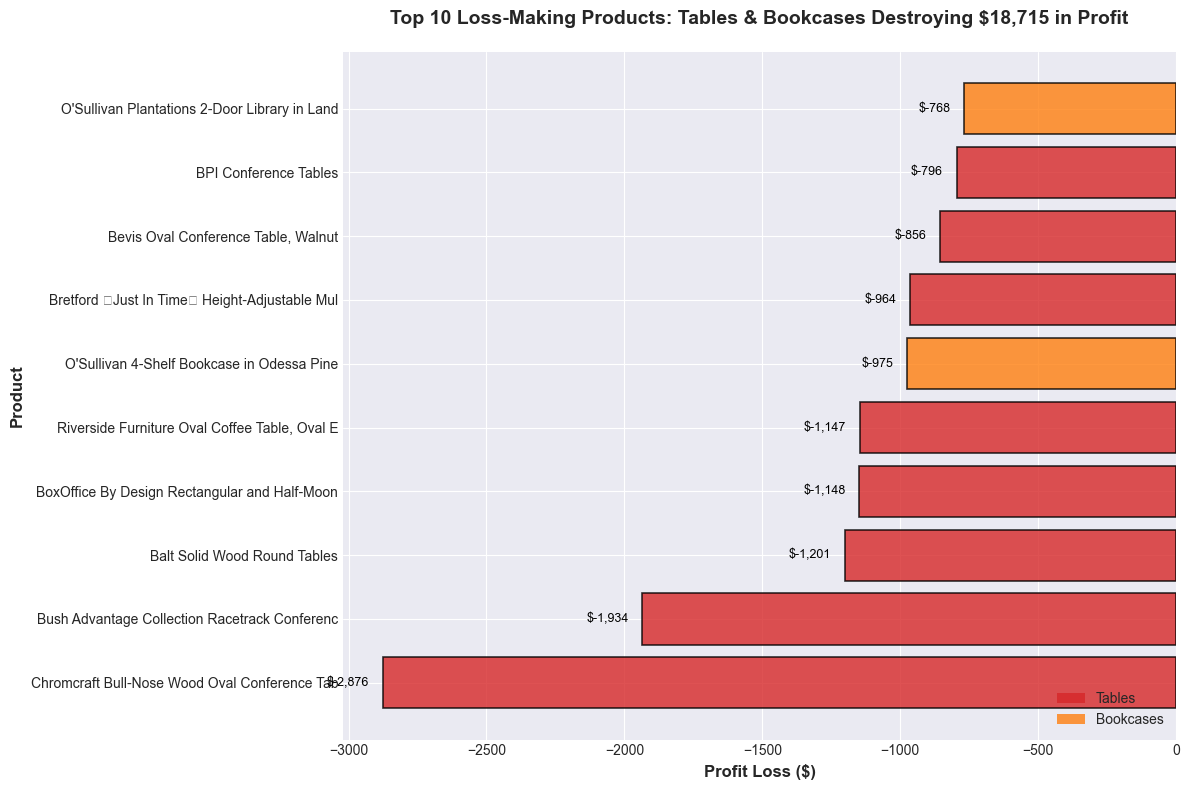

In [8]:
# ============================================================================
# VISUALIZATION 3: Top 10 Loss-Making Products
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 8))

furniture_problem = df[df['sub_category'].isin(['Tables', 'Bookcases'])].copy()
product_analysis = furniture_problem.groupby(['product_name', 'sub_category']).agg({
    'profit': 'sum',
    'sales': 'sum'
}).reset_index()

top_10_losers = product_analysis.nsmallest(10, 'profit')
top_10_losers['product_short'] = top_10_losers['product_name'].str[:45]
top_10_losers = top_10_losers.sort_values('profit')

# Color by sub-category
colors = ['#ff7f0e' if x == 'Bookcases' else '#d62728' for x in top_10_losers['sub_category']]

bars = ax.barh(top_10_losers['product_short'], top_10_losers['profit'],
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, profit) in enumerate(zip(bars, top_10_losers['profit'])):
    ax.text(profit - 50, bar.get_y() + bar.get_height()/2,
            f'${profit:,.0f}', ha='right', va='center',
            fontsize=9, color='black')

ax.set_xlabel('Profit Loss ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Loss-Making Products: Tables & Bookcases Destroying $18,715 in Profit',
             fontsize=14, fontweight='bold', pad=20)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='Tables', alpha=0.8),
                   Patch(facecolor='#ff7f0e', label='Bookcases', alpha=0.8)]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('viz3_top_losers.png', dpi=300, bbox_inches='tight')
plt.show()

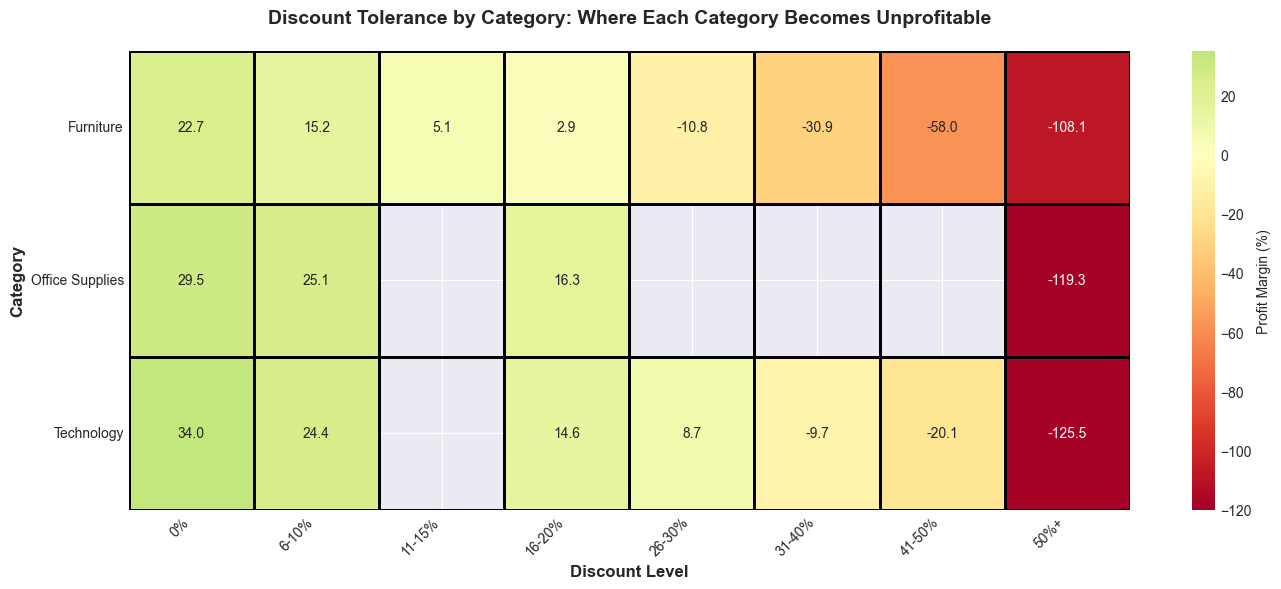

In [9]:
# ============================================================================
# VISUALIZATION 4: Category Profit Margins by Discount Level (Heatmap)
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

category_discount = df.groupby(['category', 'discount_bin'], observed=True).agg({
    'profit': 'sum',
    'sales': 'sum'
}).reset_index()
category_discount['profit_margin_%'] = (category_discount['profit'] / category_discount['sales'] * 100)

# Pivot for heatmap
heatmap_data = category_discount.pivot(index='category', columns='discount_bin', values='profit_margin_%')

# Reorder columns to ensure proper order
column_order = ['0%', '6-10%', '11-15%', '16-20%', '26-30%', '31-40%', '41-50%', '50%+']
heatmap_data = heatmap_data.reindex(columns=[c for c in column_order if c in heatmap_data.columns])

# Create heatmap with diverging colormap
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=2, linecolor='black', cbar_kws={'label': 'Profit Margin (%)'},
            vmin=-120, vmax=35, ax=ax)

ax.set_title('Discount Tolerance by Category: Where Each Category Becomes Unprofitable',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Discount Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('viz4_category_discount_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

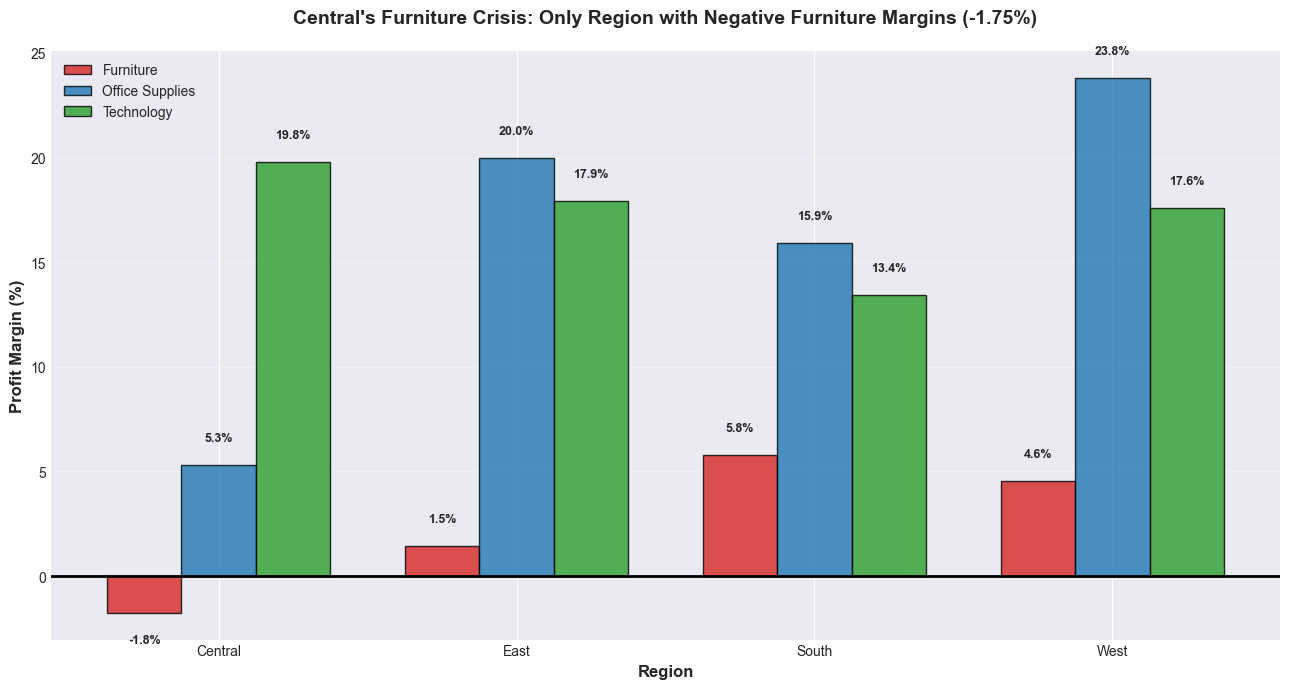

In [10]:
# ============================================================================
# VISUALIZATION 5: Regional Category Performance
# ============================================================================
fig, ax = plt.subplots(figsize=(13, 7))

region_category = df.groupby(['region', 'category']).agg({
    'sales': 'sum',
    'profit': 'sum'
}).reset_index()
region_category['profit_margin_%'] = (region_category['profit'] / region_category['sales'] * 100)

# Pivot for grouped bar chart
pivot_data = region_category.pivot(index='region', columns='category', values='profit_margin_%')

# Define colors for categories
category_colors = {'Furniture': '#d62728', 'Office Supplies': '#1f77b4', 'Technology': '#2ca02c'}

# Create grouped bar chart
x = np.arange(len(pivot_data.index))
width = 0.25

bars1 = ax.bar(x - width, pivot_data['Furniture'], width,
               label='Furniture', color=category_colors['Furniture'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, pivot_data['Office Supplies'], width,
               label='Office Supplies', color=category_colors['Office Supplies'], alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, pivot_data['Technology'], width,
               label='Technology', color=category_colors['Technology'], alpha=0.8, edgecolor='black')

# Add horizontal line at 0%
ax.axhline(y=0, color='black', linestyle='-', linewidth=2)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        label_y = height + 1 if height > 0 else height - 1
        ax.text(bar.get_x() + bar.get_width()/2., label_y,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top',
                fontweight='bold', fontsize=9)

ax.set_ylabel('Profit Margin (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_title("Central's Furniture Crisis: Only Region with Negative Furniture Margins (-1.75%)",
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(pivot_data.index)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz5_regional_category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

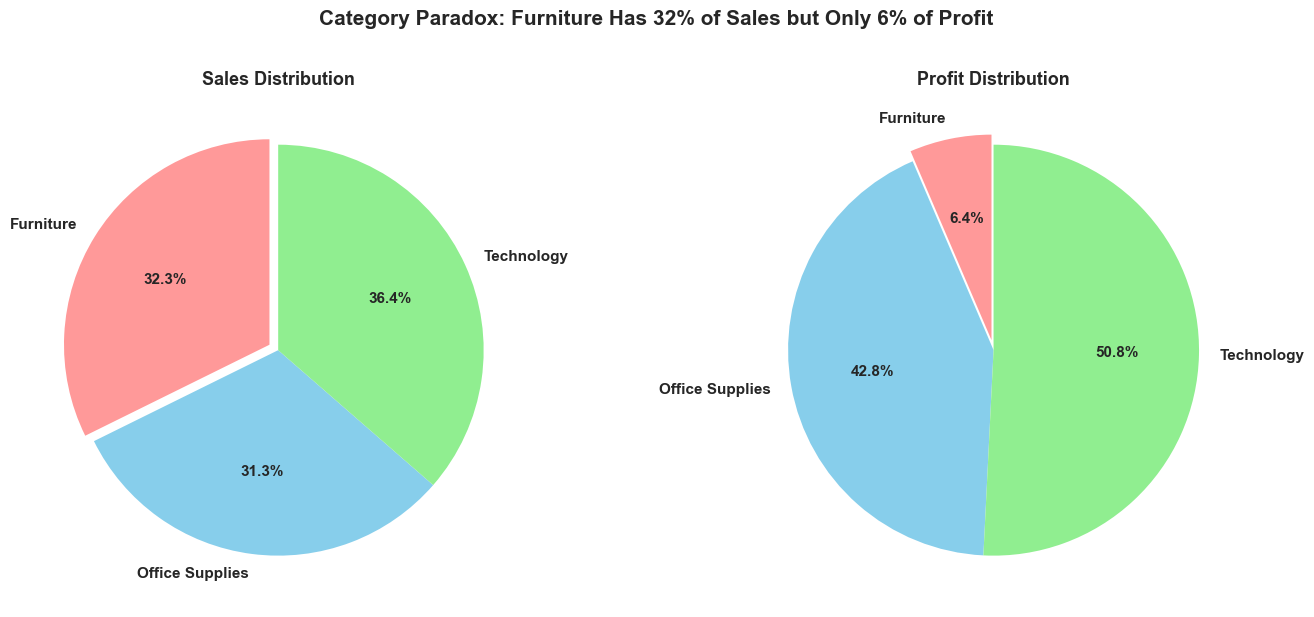


ALL VISUALIZATIONS COMPLETED!

Files saved:
  1. viz1_regional_performance.png
  2. viz2_discount_impact.png
  3. viz3_top_losers.png
  4. viz4_category_discount_heatmap.png
  5. viz5_regional_category_performance.png
  6. viz6_sales_vs_profit_contribution.png


In [11]:
# ============================================================================
# VISUALIZATION 6: Category Sales vs Profit Contribution
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

category_metrics = df.groupby('category').agg({
    'sales': 'sum',
    'profit': 'sum'
}).reset_index()

# Sales pie chart
colors_pie = ['#ff9999', '#87CEEB', '#90EE90']
explode = (0.05, 0, 0)  # Explode Furniture slice

wedges1, texts1, autotexts1 = ax1.pie(category_metrics['sales'], labels=category_metrics['category'],
                                        autopct='%1.1f%%', startangle=90, colors=colors_pie, explode=explode,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Sales Distribution', fontsize=13, fontweight='bold')

# Profit pie chart
wedges2, texts2, autotexts2 = ax2.pie(category_metrics['profit'], labels=category_metrics['category'],
                                        autopct='%1.1f%%', startangle=90, colors=colors_pie, explode=explode,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Profit Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Category Paradox: Furniture Has 32% of Sales but Only 6% of Profit',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz6_sales_vs_profit_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETED!")
print("="*80)
print("\nFiles saved:")
print("  1. viz1_regional_performance.png")
print("  2. viz2_discount_impact.png")
print("  3. viz3_top_losers.png")
print("  4. viz4_category_discount_heatmap.png")
print("  5. viz5_regional_category_performance.png")
print("  6. viz6_sales_vs_profit_contribution.png")

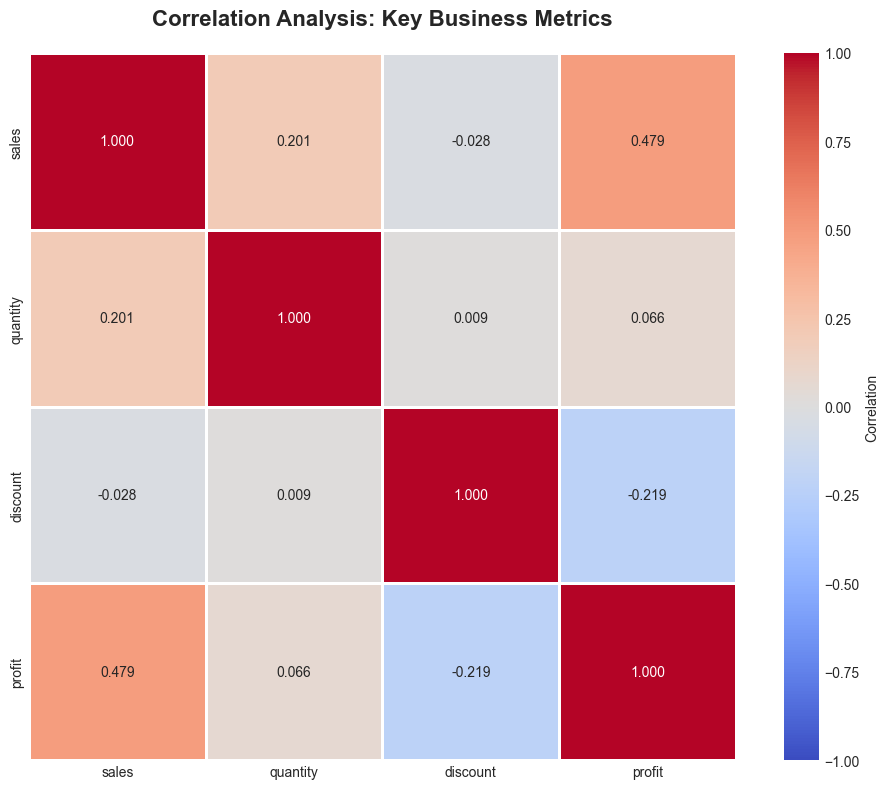

In [13]:
# ============================================================================
# VISUALIZATION 7: CORRELATION MATRIX HEATMAP
# ============================================================================
numerical_cols = ['sales', 'quantity', 'discount', 'profit']
correlation_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=2, cbar_kws={'label': 'Correlation'},
            vmin=-1, vmax=1, ax=ax)
plt.title('Correlation Analysis: Key Business Metrics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz7_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

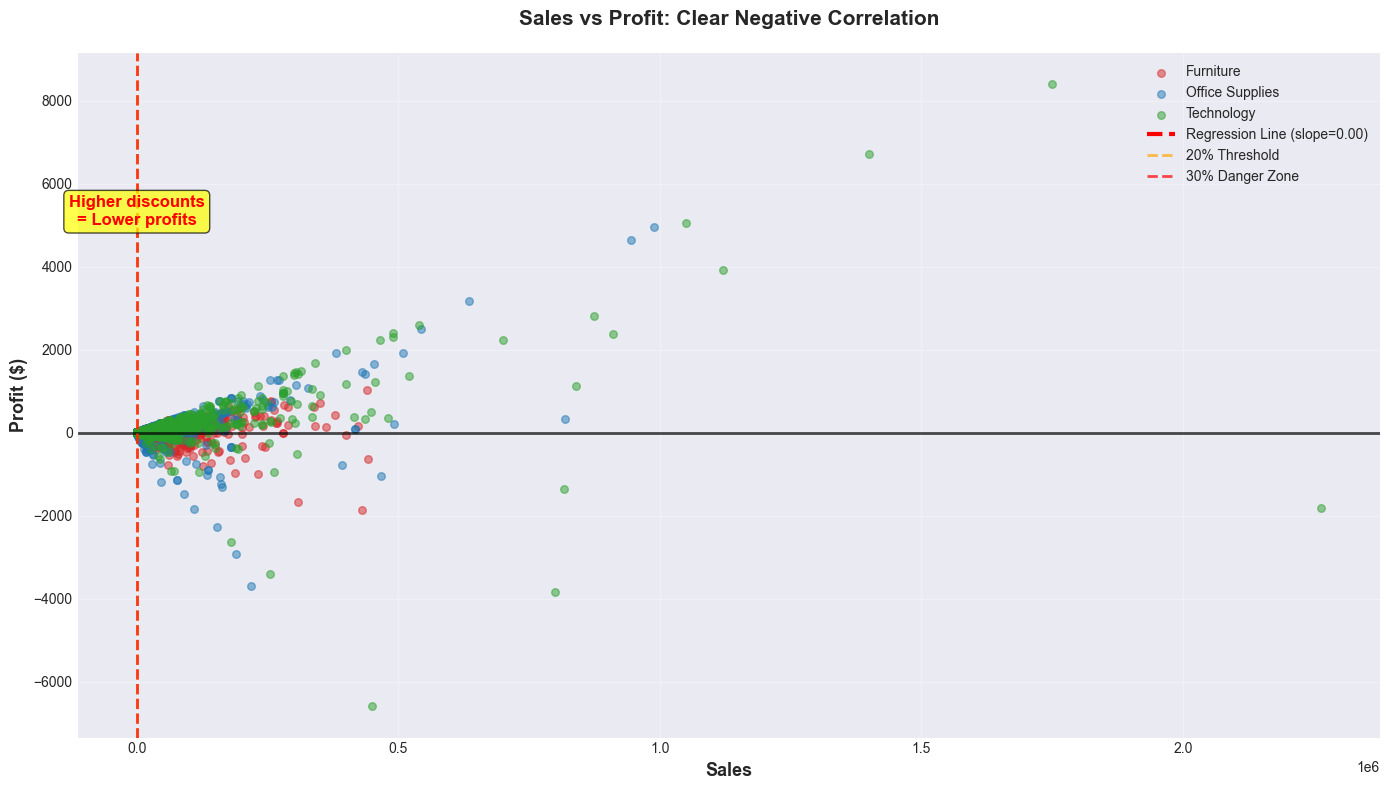

In [21]:
# ============================================================================
# VISUALIZATION 8: SCATTER PLOT - Discount vs Profit
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

categories = df['category'].unique()
colors_cat = {'Furniture': '#d62728', 'Office Supplies': '#1f77b4', 'Technology': '#2ca02c'}

for category in categories:
    cat_data = df[df['category'] == category]
    ax.scatter(cat_data['sales'] * 100, cat_data['profit'],
               alpha=0.5, s=30, label=category, color=colors_cat[category])

# Add regression line
z = np.polyfit(df['sales'] * 100, df['profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, p(x_line), "r--", linewidth=3, label=f'Regression Line (slope={z[0]:.2f})')

ax.axhline(y=0, color='black', linestyle='-', linewidth=2, alpha=0.7)
ax.axvline(x=20, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='20% Threshold')
ax.axvline(x=30, color='red', linestyle='--', linewidth=2, alpha=0.7, label='30% Danger Zone')

ax.set_xlabel('Sales', fontsize=13, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=13, fontweight='bold')
ax.set_title('Sales vs Profit: Clear Negative Correlation', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

ax.text(60, 5000, 'Higher discounts\n= Lower profits', fontsize=12,
        fontweight='bold', color='red', ha='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('viz8_sales_vs_profit_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

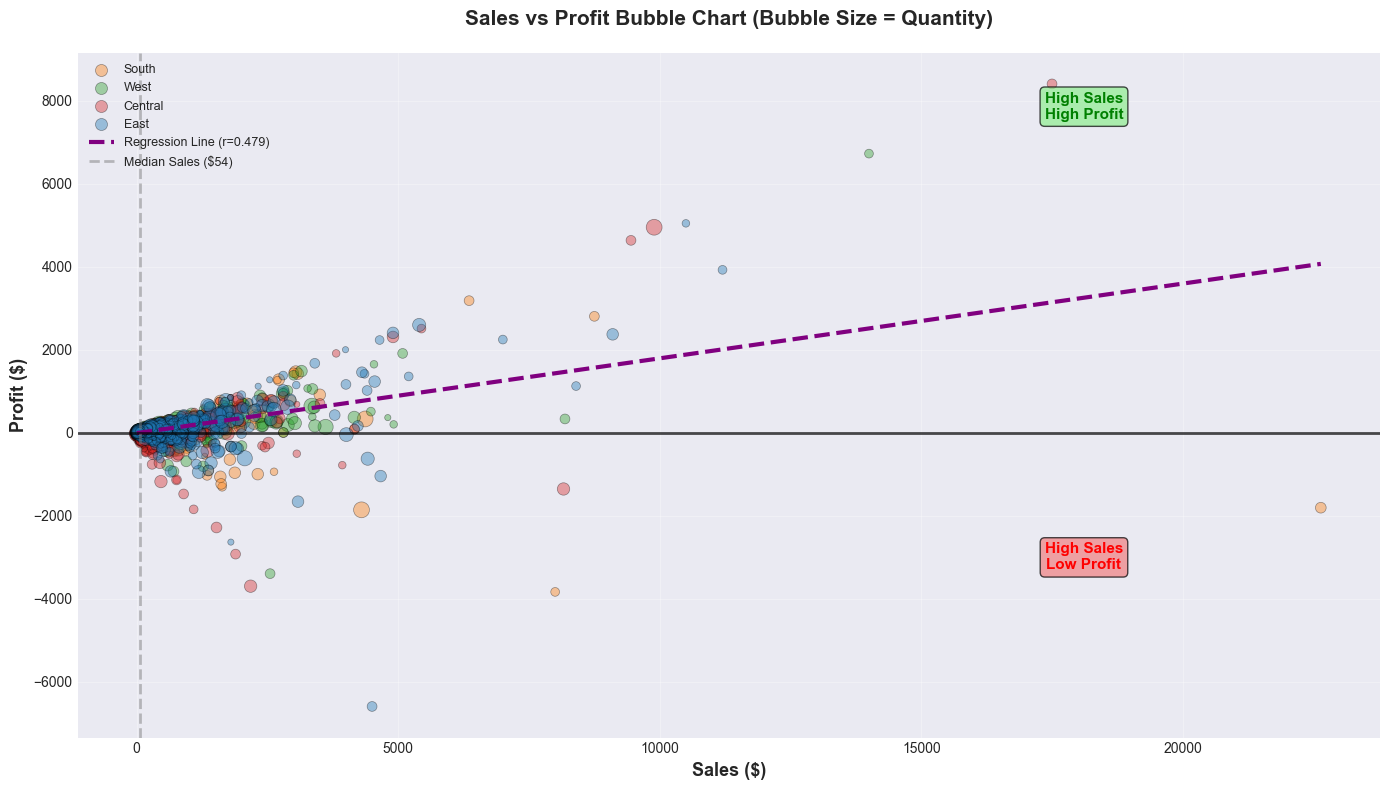

In [15]:
# ============================================================================
# VISUALIZATION 9: BUBBLE CHART - Sales vs Profit
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

regions = df['region'].unique()
colors_reg = {'Central': '#d62728', 'East': '#1f77b4', 'South': '#ff7f0e', 'West': '#2ca02c'}

for region in regions:
    reg_data = df[df['region'] == region]
    ax.scatter(reg_data['sales'], reg_data['profit'],
               s=reg_data['quantity']*10, alpha=0.4,
               label=region, color=colors_reg[region], edgecolors='black', linewidth=0.5)

# Add regression line
z = np.polyfit(df['sales'], df['profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sales'].min(), df['sales'].max(), 100)
ax.plot(x_line, p(x_line), "purple", linewidth=3, linestyle='--',
        label=f'Regression Line (r={df["sales"].corr(df["profit"]):.3f})')

ax.axhline(y=0, color='black', linestyle='-', linewidth=2, alpha=0.7)
ax.axvline(x=df['sales'].median(), color='gray', linestyle='--', linewidth=2,
           alpha=0.5, label=f'Median Sales (${df["sales"].median():.0f})')

ax.set_xlabel('Sales ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=13, fontweight='bold')
ax.set_title('Sales vs Profit Bubble Chart (Bubble Size = Quantity)',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Quadrant labels
ax.text(df['sales'].max() * 0.8, df['profit'].max() * 0.9, 'High Sales\nHigh Profit',
        fontsize=11, fontweight='bold', color='green', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.text(df['sales'].max() * 0.8, df['profit'].min() * 0.5, 'High Sales\nLow Profit',
        fontsize=11, fontweight='bold', color='red', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.savefig('viz9_sales_vs_profit_bubble.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24020\2529369943.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([df_plot[df_plot['category'] == cat]['profit']
C:\Users\HP\AppData\Local\Temp\ipykernel_24020\2529369943.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([df_plot[df_plot['segment'] == seg]['profit']


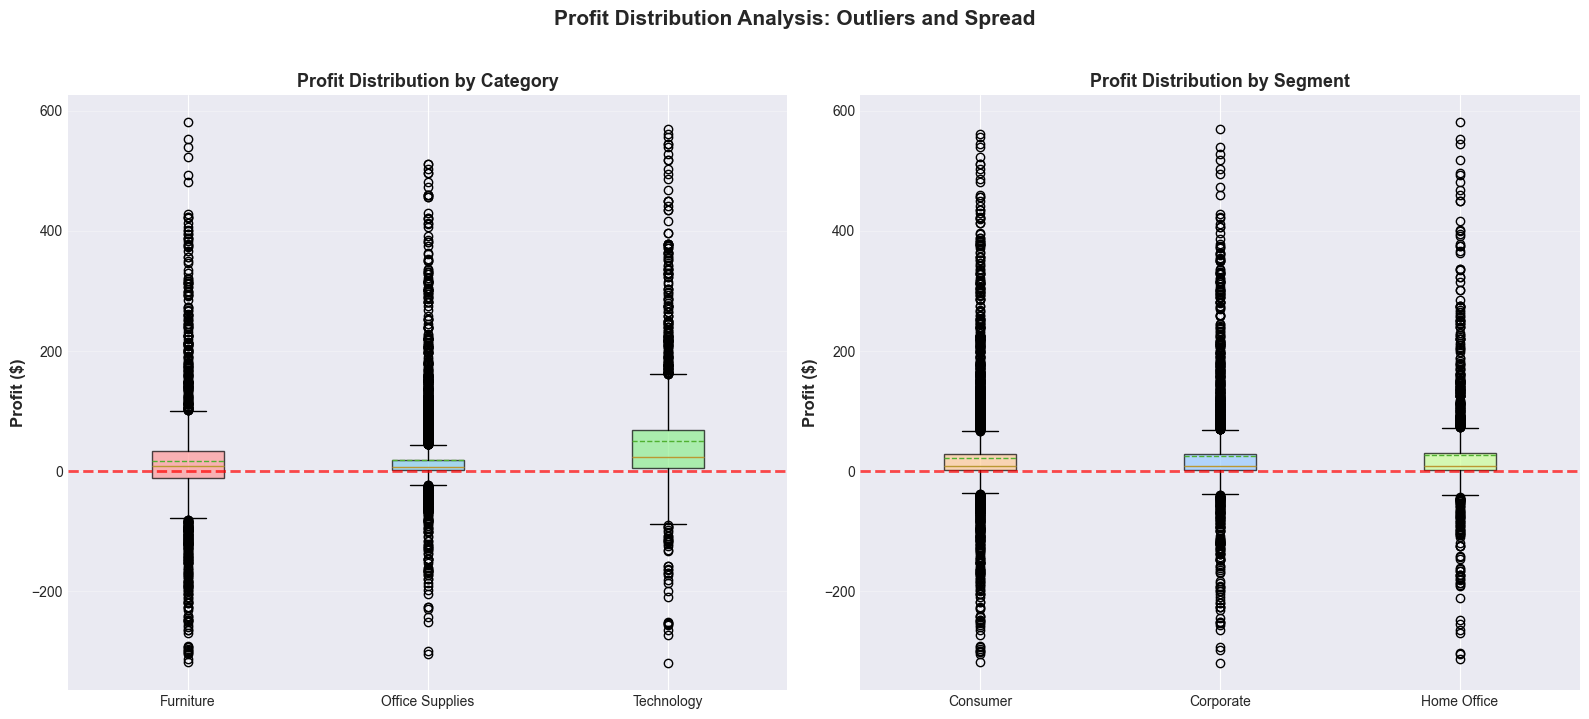

In [16]:
# ============================================================================
# VISUALIZATION 10: BOX PLOTS - Profit Distribution
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Filter outliers for better visualization
df_plot = df[df['profit'].between(df['profit'].quantile(0.01), df['profit'].quantile(0.99))]

# Box plot by category
bp1 = ax1.boxplot([df_plot[df_plot['category'] == cat]['profit']
                   for cat in ['Furniture', 'Office Supplies', 'Technology']],
                   labels=['Furniture', 'Office Supplies', 'Technology'],
                   patch_artist=True, showmeans=True, meanline=True)

colors = ['#ff9999', '#87CEEB', '#90EE90']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
ax1.set_title('Profit Distribution by Category', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Box plot by segment
bp2 = ax2.boxplot([df_plot[df_plot['segment'] == seg]['profit']
                   for seg in ['Consumer', 'Corporate', 'Home Office']],
                   labels=['Consumer', 'Corporate', 'Home Office'],
                   patch_artist=True, showmeans=True, meanline=True)

colors2 = ['#ffcc99', '#99ccff', '#ccff99']
for patch, color in zip(bp2['boxes'], colors2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
ax2.set_title('Profit Distribution by Segment', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Profit Distribution Analysis: Outliers and Spread',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz10_profit_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

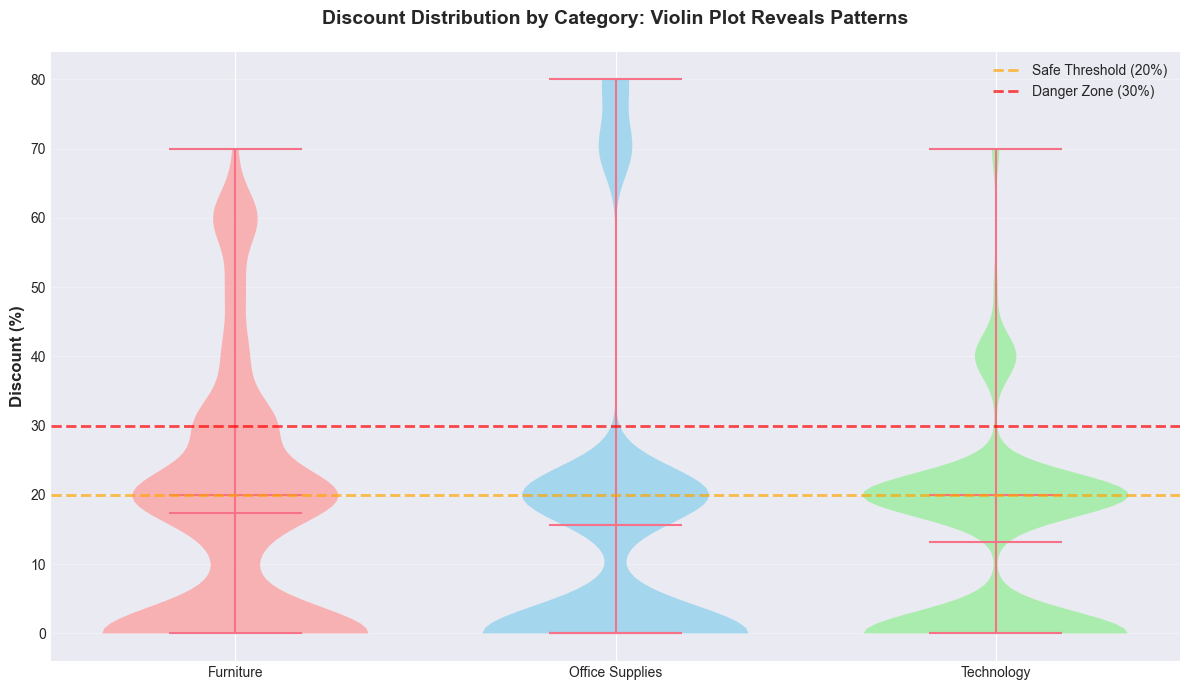


All visualizations completed successfully!


In [17]:
# ============================================================================
# VISUALIZATION 11: VIOLIN PLOT - Discount Distribution
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7))

violin_data = [df[df['category'] == cat]['discount'] * 100
               for cat in ['Furniture', 'Office Supplies', 'Technology']]

parts = ax.violinplot(violin_data, positions=[1, 2, 3],
                      showmeans=True, showmedians=True, widths=0.7)

colors = ['#ff9999', '#87CEEB', '#90EE90']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Furniture', 'Office Supplies', 'Technology'])
ax.set_ylabel('Discount (%)', fontsize=12, fontweight='bold')
ax.set_title('Discount Distribution by Category: Violin Plot Reveals Patterns',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

ax.axhline(y=20, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Safe Threshold (20%)')
ax.axhline(y=30, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Danger Zone (30%)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('viz11_discount_violin.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAll visualizations completed successfully!")

## 📊 Executive Summary: Unprofitable Furniture Sales in the Central Region

The current analysis highlights a significant issue where **Furniture sales are consistently unprofitable** due to the application of overly large discounts. This problem is particularly acute within the **Central Region**.

---

## 🎯 Key Findings and Focus Area

### 1. Unprofitability Driver: High Discounts

* Furniture items are being sold at a loss, indicating that discounts are reaching levels that make sales unprofitable.

### 2. Geographic Hotspot: Central Region

* The **Central Region** is the primary driver of this issue, showing the highest frequency of large discounts that result in overall profit losses, especially within the Furniture category.

---

## 🧐 Recommended Investigation & Assumed Causes

**Immediate action is required:** An investigation into the justifications for the high discounts on furniture in the Central Region must be initiated.

### Assumed Causes for High Discounts:

Based on business context, the reasons for these high discounts likely fall into two main categories:

| Category | Description |
| --- | --- |
| **Inventory Management Issues** | Items may be piling up in stock, and the sales velocity is not continuous, necessitating deep discounts to move inventory and clear warehouse space. |
| **Deterioration or Holding Costs** | The cost of keeping the items in inventory (storage, insurance, capital tie-up) is assumed to be higher than the loss incurred from selling them at a deep discount. |
| **Product Integrity Loss** | **Partial loss or damage** to the furniture items may be a factor. For example, damage due to pests like **termites** could necessitate immediate liquidation at any cost to minimize further loss. |

---

## ⏭️ Management Recommendation

Since the available data does not permit further conclusive analysis into the specific reasons for the losses, the following step is recommended:

* **Management must hear directly from the Central Region branch** to obtain detailed justifications and evidence regarding the significant discounts applied to the Furniture category.

Would you like me to draft a more formal memo or a list of specific questions for the Central Region branch manager?